# CNN전이학습_data_augmentation
* 전이학습: 사전에 훈련된 모델을 가져와서 사용하는 것
* data_agmentation: 이미지 데이터의 경우 데이터가 적어서 확보가 어려움, 비쌈, 기존 이미지데이터에 변형을 가해서 데이터 수를 늘리는 작업(회전, 확대, 축소, 자르기)

# Image Augmentation
* 학습데이터 부족을 해결하기 위해서 이미지에 변형을 가해 새로운 이미지를 만들어 주는 것

In [4]:
from keras.preprocessing.image import img_to_array, array_to_img, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
image = load_img("../data/catanddog/bird.jpg")
image_array = img_to_array(image)
image_array.shape

(703, 454, 3)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

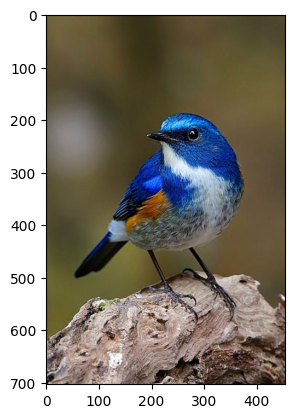

In [7]:
plt.imshow(image)
plt.show()

이미지 증폭

In [8]:
imggen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=40,
        width_shift_range=0.3,
        height_shift_range=0.2,
        shear_range=0.6,
        zoom_range=0.3,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest')

이미지 차원 늘리기

In [9]:
image_array.shape

(703, 454, 3)

In [10]:
(1, ) + image_array.shape

(1, 703, 454, 3)

In [12]:
image_array.reshape((1,) + image_array.shape).shape

(1, 703, 454, 3)

In [13]:
image_array = image_array.reshape((1,) + image_array.shape)
image_array.shape

(1, 703, 454, 3)

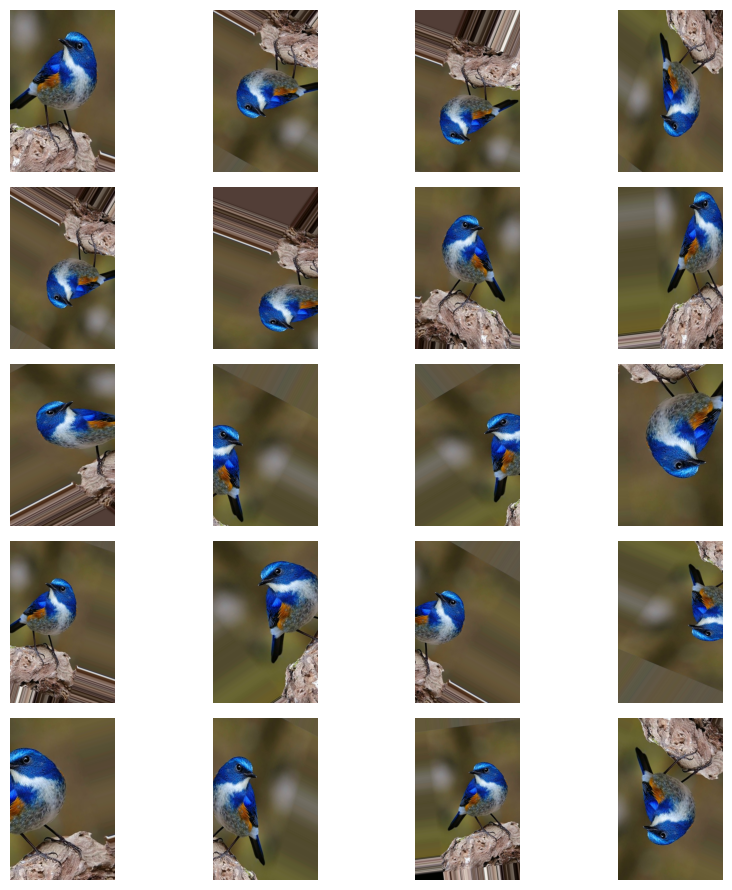

In [14]:
fig, axes = plt.subplots(5, 4, figsize=(9,9))
axes = axes.ravel()

for i, batch in enumerate(imggen.flow(image_array, batch_size=1)):
    if i >= 20:
        break
    augmented_image = array_to_img(batch[0])
    axes[i].imshow(augmented_image)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# image_augmentation을 이용한 개/고양이 분류 모델 만들기

In [2]:
# 데이터 로드
train_dir = "../data/catanddog/train/"
valid_dir = "../data/catanddog/validation/"
batch_size = 16 # 한 번에 불러오는 사진의 개수 16 - 32 개 사이로 지정
image_size = (224, 224)  # 모델의 입력 크기에 맞춤

In [5]:
# 이미지 증강 훈련데이터에만 적용
train_aug = ImageDataGenerator(
        rescale=1./255,
        rotation_range=40,
        width_shift_range=0.3,
        height_shift_range=0.2,
        shear_range=0.6,
        zoom_range=0.3,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
        )

valid_aug = ImageDataGenerator(rescale=1./255)

# 모든 데이터에 이미지 증강
train_gen = train_aug.flow_from_directory(
            train_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42
            )

valid_gen = valid_aug.flow_from_directory(
            valid_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42
            )

X_batch, y_batch = next(train_gen)
print(X_batch.shape)
print(y_batch.shape)
print(train_gen.class_indices)


Found 385 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


# CNN을 이용한 개/고양이 분류

In [6]:
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [7]:
model = Sequential()
model.add(Input(shape=X_batch.shape[1:]))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
model.add(Dropout(0.25))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
model.add(Dropout(0.25))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))
model.summary()

I0000 00:00:1773974366.368344    1976 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 220, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 106, 106, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 51, 51, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 51, 51, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 49, 49, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 49, 49, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,462,626 (9.39 MB)

 Trainable params: 2,461,858 (9.39 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/1000


2026-03-20 11:39:35.399329: I external/local_xla/xla/service/service.cc:163] XLA service 0x76ec3400d990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-20 11:39:35.399377: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2026-03-20 11:39:35.531039: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-20 11:39:36.223506: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92000
2026-03-20 11:39:37.563330: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,32,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,224,224]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudn

18/25 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.5032 - loss: 1.0167

2026-03-20 11:40:05.590277: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1,32,49,49]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,32,51,51]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-20 11:40:06.280632: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 11:40:06.493670: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-op

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 757ms/step - accuracy: 0.5091 - loss: 0.9992

...

25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 764ms/step - accuracy: 0.6701 - loss: 0.5848 - val_accuracy: 0.5000 - val_loss: 0.8733
Epoch 51/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 753ms/step - accuracy: 0.6286 - loss: 0.6489 - val_accuracy: 0.5102 - val_loss: 0.7945
Epoch 52/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 574ms/step - accuracy: 0.6883 - loss: 0.6081 - val_accuracy: 0.5510 - val_loss: 0.7510
Epoch 53/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 652ms/step - accuracy: 0.6390 - loss: 0.6347 - val_accuracy: 0.5510 - val_loss: 0.7683
Epoch 54/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 748ms/step - accuracy: 0.6961 - loss: 0.5838 - val_accuracy: 0.5408 - val_loss: 0.7587
Epoch 55/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 626ms/step - accuracy: 0.6649 - loss: 0.5973 - val_accuracy: 0.5612 - val_loss: 0.7321
Epoch 56/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 676ms/step - accuracy: 0.6597 - loss: 0.5977 - val_accuracy: 0.6020 - val_loss: 0.6862
Epoch 57/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 728ms/step - accuracy: 0.6857 - loss: 0.5839 

25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 618ms/step - accuracy: 0.7351 - loss: 0.5309 - val_accuracy: 0.6735 - val_loss: 0.6409
Epoch 100/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 493ms/step - accuracy: 0.7870 - loss: 0.4977 - val_accuracy: 0.6735 - val_loss: 0.6093
Epoch 101/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 637ms/step - accuracy: 0.7403 - loss: 0.5239 - val_accuracy: 0.6020 - val_loss: 0.7773
Epoch 102/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 718ms/step - accuracy: 0.7403 - loss: 0.5055 - val_accuracy: 0.6122 - val_loss: 0.7594
Epoch 103/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 557ms/step - accuracy: 0.6831 - loss: 0.5581 - val_accuracy: 0.5918 - val_loss: 0.7944
Epoch 104/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 547ms/step - accuracy: 0.7688 - loss: 0.4887 - val_accuracy: 0.6531 - val_loss: 0.6732
Epoch 105/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 589ms/step - accuracy: 0.7377 - loss: 0.5174 - val_accuracy: 0.6735 - val_loss: 0.5745
Epoch 106/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 606ms/step - accuracy: 0.7740 - loss: 

25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 518ms/step - accuracy: 0.7429 - loss: 0.5259 - val_accuracy: 0.6633 - val_loss: 0.7121
Epoch 149/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 548ms/step - accuracy: 0.7506 - loss: 0.4898 - val_accuracy: 0.5918 - val_loss: 0.8119
Epoch 150/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 591ms/step - accuracy: 0.7870 - loss: 0.4406 - val_accuracy: 0.6531 - val_loss: 0.9044
Epoch 151/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 603ms/step - accuracy: 0.7740 - loss: 0.4736 - val_accuracy: 0.6224 - val_loss: 0.9733
Epoch 152/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 518ms/step - accuracy: 0.8208 - loss: 0.4110 - val_accuracy: 0.5204 - val_loss: 2.2036
Epoch 153/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 609ms/step - accuracy: 0.7974 - loss: 0.4480 - val_accuracy: 0.6837 - val_loss: 0.7662
Epoch 154/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 632ms/step - accuracy: 0.8364 - loss: 0.3837 - val_accuracy: 0.6327 - val_loss: 0.8195
Epoch 155/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 468ms/step - accuracy: 0.7844 - loss: 

25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 511ms/step - accuracy: 0.8234 - loss: 0.3748 - val_accuracy: 0.7041 - val_loss: 0.6397
Epoch 198/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 671ms/step - accuracy: 0.7870 - loss: 0.4352 - val_accuracy: 0.7347 - val_loss: 0.6784
Epoch 199/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 631ms/step - accuracy: 0.8130 - loss: 0.3909 - val_accuracy: 0.7449 - val_loss: 0.6107
Epoch 200/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 541ms/step - accuracy: 0.8026 - loss: 0.3717 - val_accuracy: 0.6837 - val_loss: 0.7991
Epoch 201/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 598ms/step - accuracy: 0.8312 - loss: 0.3675 - val_accuracy: 0.6327 - val_loss: 0.9188
Epoch 202/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 619ms/step - accuracy: 0.8494 - loss: 0.3522 - val_accuracy: 0.7857 - val_loss: 0.6139
Epoch 203/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 598ms/step - accuracy: 0.8338 - loss: 0.3994 - val_accuracy: 0.7245 - val_loss: 0.6977
Epoch 204/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 519ms/step - accuracy: 0.8286 - loss: 

25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 559ms/step - accuracy: 0.8545 - loss: 0.3593 - val_accuracy: 0.7347 - val_loss: 0.6170
Epoch 247/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 662ms/step - accuracy: 0.8364 - loss: 0.3435 - val_accuracy: 0.5612 - val_loss: 0.9338
Epoch 248/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 663ms/step - accuracy: 0.8727 - loss: 0.2980 - val_accuracy: 0.7245 - val_loss: 0.6965
Epoch 249/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 665ms/step - accuracy: 0.8649 - loss: 0.3020 - val_accuracy: 0.6531 - val_loss: 1.0187
Epoch 250/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 611ms/step - accuracy: 0.8623 - loss: 0.3113 - val_accuracy: 0.7143 - val_loss: 0.6660
Epoch 251/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 638ms/step - accuracy: 0.8753 - loss: 0.3101 - val_accuracy: 0.7143 - val_loss: 0.7176
Epoch 252/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 657ms/step - accuracy: 0.8571 - loss: 0.3496 - val_accuracy: 0.6633 - val_loss: 0.7819
Epoch 253/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 446ms/step - accuracy: 0.8649 - loss: 

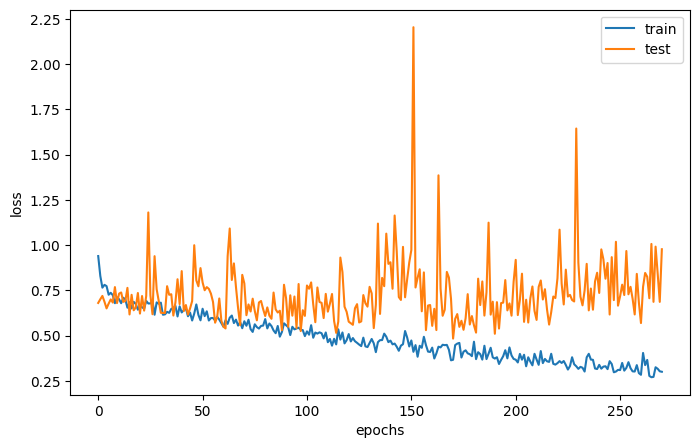

In [8]:
model.compile(loss="categorical_crossentropy",
             optimizer='adam',
             metrics=['accuracy'])
model_path = "./model/catndog_cnn_model.keras"
model_save = ModelCheckpoint(filepath=model_path, save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
history = model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                   callbacks=[model_save, early_stop])
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'test'])
plt.show()

In [9]:
class_indices = valid_gen.class_indices
class_indices

{'Cat': 0, 'Dog': 1}

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


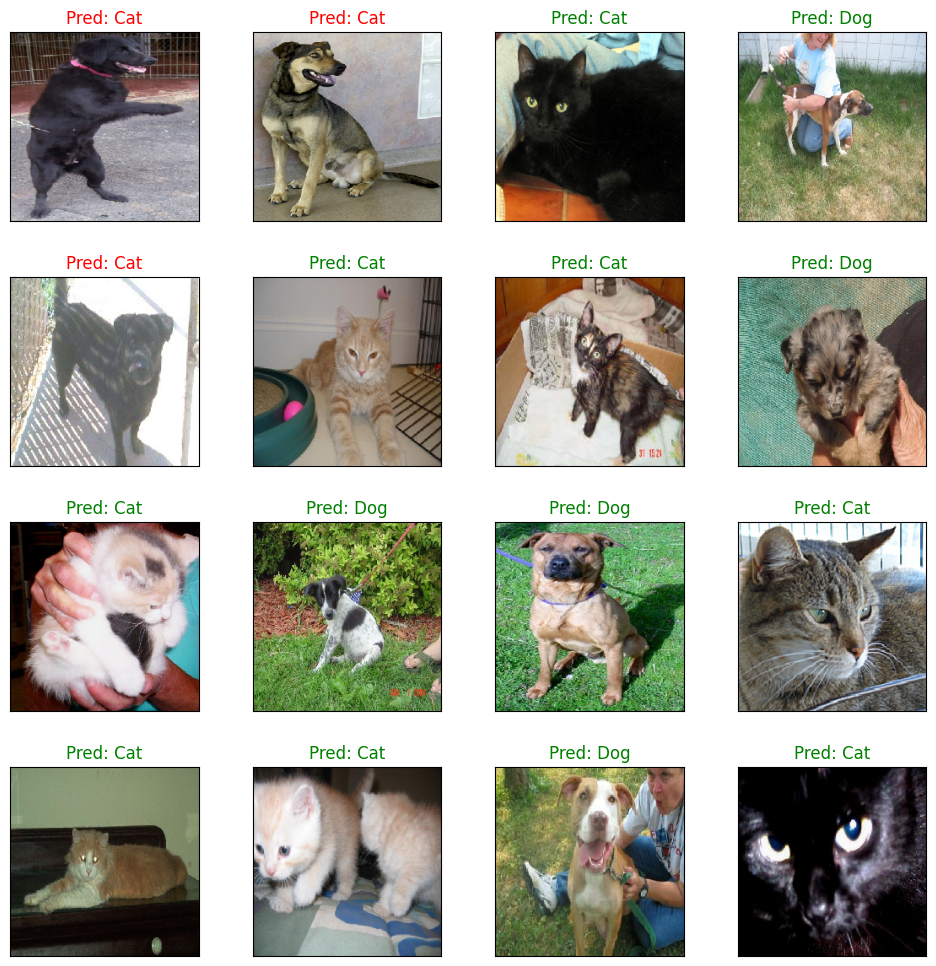


cnn_best_model평가 결과: Loss: 0.3146, Accuracy: 0.8125


In [15]:
# best 모델 로드
cnn_best_model = load_model("./model/catndog_cnn_model.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

cnn_pred = cnn_best_model.predict(validation_batch)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = cnn_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\ncnn_best_model평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# ResNet50
* ResNet50에 사용할 경우, rescale=1./255는 제거하고 preprocessing_function=preprocess_input을 사용
* Keras의 ResNet50은 입력 이미지를 BGR로 바꾸고 채널별 평균을 빼는 전처리를 필요로 하기 때문

In [16]:
from tensorflow.keras.layers import GlobalMaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50, ResNet152V2
from tensorflow.keras.applications.resnet import preprocess_input
import tensorflow as tf

In [18]:
# ✅ ResNet50에 맞는 이미지 증강기 (rescale 제거 → preprocess_input 사용)
train_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ✔️ ResNet 전용 전처리
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.2,
    shear_range=0.6,
    zoom_range=0.3,
    fill_mode='nearest'
)

valid_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input  # ✔️ Validation도 동일하게 처리
)

# ✅ 이미지 제너레이터 생성
train_gen = train_aug.flow_from_directory(
    train_dir,
    target_size=image_size,  # 예: (224, 224)
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

valid_gen = valid_aug.flow_from_directory(
    valid_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

# ✅ 배치 확인
X_batch, y_batch = next(train_gen)
print(X_batch.shape)  # 예: (32, 224, 224, 3)
print(y_batch.shape)
print(train_gen.class_indices)

Found 385 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


In [19]:
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_tensor=None,
    input_shape=(224,224,3),
    pooling='avg')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [21]:
base_model.trainable = False
res50_model = Sequential()
res50_model.add(base_model)
res50_model.add(Dense(2, activation='softmax'))
res50_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [22]:
res50_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/res50_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
res50_history = res50_model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])

Epoch 1/1000


2026-03-20 13:43:47.104632: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,56,56]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-20 13:43:47.640951: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 676.06MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-03-20 13:43:48.182122: I external/local

 5/25 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step - accuracy: 0.4433 - loss: 0.8899

2026-03-20 13:43:55.702301: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1,128,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,128,28,28]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-20 13:43:56.149656: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1,256,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,256,14,14]{3,2,1,0}, f32[256,256,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_targe

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.4273 - loss: 0.9827

...

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9947 - loss: 0.0495
Epoch 42: val_loss improved from 0.09907 to 0.09630, saving model to ./model/res50_catndog.keras

Epoch 42: finished saving model to ./model/res50_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 619ms/step - accuracy: 0.9870 - loss: 0.0575 - val_accuracy: 0.9796 - val_loss: 0.0963
Epoch 43/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9736 - loss: 0.0605
Epoch 43: val_loss did not improve from 0.09630
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 672ms/step - accuracy: 0.9766 - loss: 0.0615 - val_accuracy: 0.9796 - val_loss: 0.1003
Epoch 44/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.9902 - loss: 0.0553
Epoch 44: val_loss did not improve from 0.09630
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 576ms/step - accuracy: 0.9818 - loss: 0.0622 - val_accuracy: 0.9796 - val_loss: 0.0995
Epoch 45/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.9887 - loss: 0.0467
Epoch 45: val_loss did not improve from 0.09630

Epoch 66/1000
23/25 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step - accuracy: 0.9924 - loss: 0.0398
Epoch 66: val_loss did not improve from 0.08453
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 803ms/step - accuracy: 0.9922 - loss: 0.0409 - val_accuracy: 0.9796 - val_loss: 0.0903
Epoch 67/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.9773 - loss: 0.0557
Epoch 67: val_loss did not improve from 0.08453
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 574ms/step - accuracy: 0.9844 - loss: 0.0488 - val_accuracy: 0.9796 - val_loss: 0.0887
Epoch 68/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.9814 - loss: 0.0399
Epoch 68: val_loss did not improve from 0.08453
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 708ms/step - accuracy: 0.9818 - loss: 0.0459 - val_accuracy: 0.9796 - val_loss: 0.0920
Epoch 69/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.9750 - loss: 0.0515
Epoch 69: val_loss did not improve from 0.08453
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 734ms/step - accuracy: 0.9792 - loss: 0.0484 - val_accuracy: 0.9796

Epoch 90/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.9913 - loss: 0.0272
Epoch 90: val_loss did not improve from 0.07804
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 746ms/step - accuracy: 0.9922 - loss: 0.0308 - val_accuracy: 0.9796 - val_loss: 0.0846
Epoch 91/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.9998 - loss: 0.0230
Epoch 91: val_loss did not improve from 0.07804
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 828ms/step - accuracy: 0.9974 - loss: 0.0283 - val_accuracy: 0.9796 - val_loss: 0.0845
Epoch 92/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.9931 - loss: 0.0275
Epoch 92: val_loss did not improve from 0.07804
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 766ms/step - accuracy: 0.9922 - loss: 0.0283 - val_accuracy: 0.9796 - val_loss: 0.0874
Epoch 93/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.9901 - loss: 0.0321
Epoch 93: val_loss did not improve from 0.07804
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 889ms/step - accuracy: 0.9922 - loss: 0.0291 - val_accuracy: 0.9796

Epoch 115/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.9981 - loss: 0.0228
Epoch 115: val_loss did not improve from 0.07660
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 632ms/step - accuracy: 0.9948 - loss: 0.0246 - val_accuracy: 0.9796 - val_loss: 0.0848
Epoch 116/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.9975 - loss: 0.0233
Epoch 116: val_loss did not improve from 0.07660
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 732ms/step - accuracy: 0.9948 - loss: 0.0281 - val_accuracy: 0.9796 - val_loss: 0.0846
Epoch 117/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.9964 - loss: 0.0222
Epoch 117: val_loss did not improve from 0.07660
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 613ms/step - accuracy: 0.9948 - loss: 0.0251 - val_accuracy: 0.9796 - val_loss: 0.0796
Epoch 118/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.9986 - loss: 0.0198
Epoch 118: val_loss did not improve from 0.07660
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 614ms/step - accuracy: 0.9948 - loss: 0.0229 - val_accuracy

Epoch 140/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.9901 - loss: 0.0339
Epoch 140: val_loss did not improve from 0.07304
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 856ms/step - accuracy: 0.9896 - loss: 0.0297 - val_accuracy: 0.9796 - val_loss: 0.0852
Epoch 141/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9997 - loss: 0.0209
Epoch 141: val_loss did not improve from 0.07304
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9974 - loss: 0.0197 - val_accuracy: 0.9796 - val_loss: 0.0815
Epoch 142/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 1.0000 - loss: 0.0131
Epoch 142: val_loss did not improve from 0.07304
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 879ms/step - accuracy: 1.0000 - loss: 0.0147 - val_accuracy: 0.9796 - val_loss: 0.0898
Epoch 143/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.9981 - loss: 0.0158
Epoch 143: val_loss did not improve from 0.07304
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 656ms/step - accuracy: 0.9974 - loss: 0.0195 - val_accuracy: 0.96

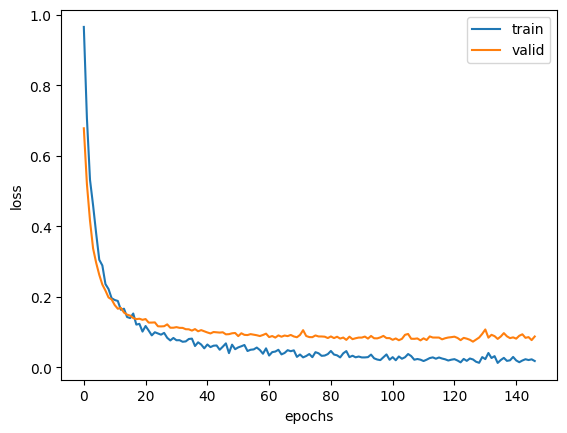

In [23]:
plt.plot(res50_history.history['loss'])
plt.plot(res50_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 796ms/step

[전체 Validation Accuracy] 0.5918
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


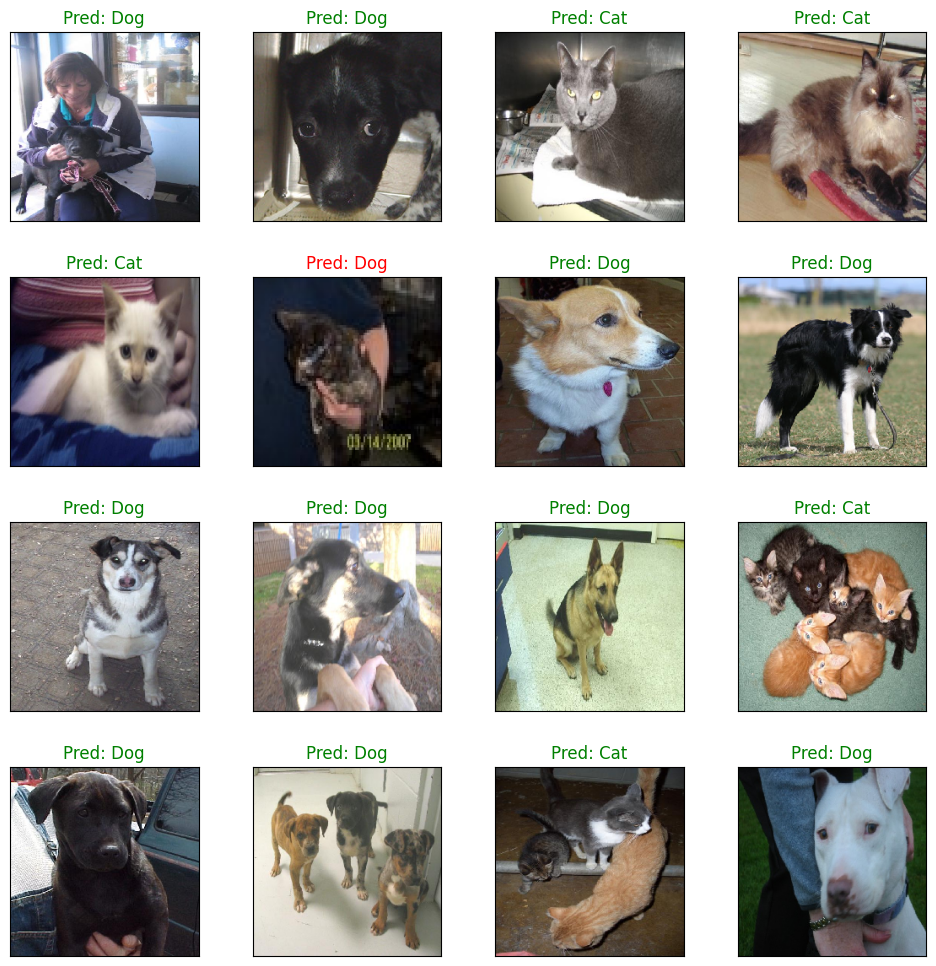

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 643ms/step - accuracy: 0.9796 - loss: 0.0730

[모델 평가 결과] Loss: 0.0730, Accuracy: 0.9796


In [24]:
from sklearn.metrics import accuracy_score
# ✅ 모델 로드
res50_best_model = load_model("./model/res50_catndog.keras")

# ✅ 클래스 이름 추출
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]

# ✅ 전체 validation 데이터로 예측
cnn_pred = res50_best_model.predict(valid_gen, verbose=1)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = valid_gen.classes  # 전체 정답

# ✅ 정확도 출력
acc = accuracy_score(true_values, pred_values)
print(f"\n[전체 Validation Accuracy] {acc:.4f}")

# ✅ 시각화용: 소량 배치만 가져오기
sample_batch, label_batch = next(valid_gen)
sample_pred = res50_best_model.predict(sample_batch)
sample_pred_values = np.argmax(sample_pred, axis=1)
sample_true_values = np.argmax(label_batch, axis=1)

# ✅ 시각화: 이미지 복구 후 출력
def deprocess_input(x):
    """ResNet의 preprocess_input을 반대로 적용 (BGR→RGB + 평균값 복원)"""
    x = x.copy()
    # ImageNet 평균값 (BGR 순)
    mean = [103.939, 116.779, 123.68]
    x[..., 0] += mean[0]  # B
    x[..., 1] += mean[1]  # G
    x[..., 2] += mean[2]  # R
    x = x[..., ::-1]  # BGR → RGB
    return np.clip(x / 255.0, 0, 1)  # matplotlib은 0~1 사이값을 기대함

# ✅ 이미지 시각화
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(hspace=0.3)
num_images = min(16, sample_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    img = deprocess_input(sample_batch[i])
    ax.imshow(img)
    pred_label = class_names[sample_pred_values[i]]
    true_label = class_names[sample_true_values[i]]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# ✅ 전체 평가
loss, acc = res50_best_model.evaluate(valid_gen, verbose=1)
print(f"\n[모델 평가 결과] Loss: {loss:.4f}, Accuracy: {acc:.4f}")